# Phân Tích Khám Phá Dữ Liệu (EDA)

Notebook này thực hiện toàn bộ quá trình khám phá và tiền xử lý dữ liệu trước khi đưa vào huấn luyện mô hình.

**Dataset:** Malicious URLs Detection Dataset - 651,191 URLs, 59 features, 4 classes  
**Output:** Hai pipeline dữ liệu phân chia cho mô hình Machine Learning (`df_tab`) và Deep learning (`df_seq`)

> Đặt file `final_dataset_with_all_features_v3.1.csv` vào thư mục gốc của project trước khi chạy.

## 1. Import & Load Dataset

In [3]:
#Import và load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('../final_dataset_with_all_features_v3.1.csv')
print("Shape:", df.shape)
df.head()

Shape: (651191, 64)


,url,type,label,url_len,@,?,-,=,.,#,...,phish_adv_long_domain,phish_adv_many_subdomains,phish_adv_encoded_chars,phish_adv_path_keywords,phish_adv_has_redirect,phish_adv_many_params,path_has_hacked_terms,suspicious_extension,path_underscore_count,is_gov_edu
0,br-icloud.com.br,phishing,2,16,0,0,1,0,2,0,...,0,0,0,0,0,0,0,0,0,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,0,0,0,0,2,0,...,0,0,0,0,0,0,0,1,1,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,0,0,0,0,2,0,...,0,0,0,0,0,0,0,1,0,0
3,http://garage-pirenne.be/index.php?option=com_...,defacement,1,84,0,1,1,4,2,0,...,0,0,0,0,0,3,0,1,0,0
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,0,1,1,3,2,0,...,0,0,0,0,0,2,0,1,0,0


## 2. Tổng Quan Dataset

Kiểm tra kích thước, kiểu dữ liệu, missing values và thống kê cơ bản.

In [4]:
#Thông tin tổng quan
print("=== THÔNG TIN DATASET ===")
print(f"Số dòng: {df.shape[0]:,}")
print(f"Số features: {df.shape[1]}")
print(f"\n=== KIỂU DỮ LIỆU ===")
print(df.dtypes.value_counts())
print(f"\n=== MISSING VALUES ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Không có missing values")
print(f"\n=== THỐNG KÊ CƠ BẢN ===")
df.describe()

=== THÔNG TIN DATASET ===
Số dòng: 651,191
Số features: 64

=== KIỂU DỮ LIỆU ===
int64      59
str         4
float64     1
Name: count, dtype: int64

=== MISSING VALUES ===
domain    12223
dtype: int64

=== THỐNG KÊ CƠ BẢN ===


,label,url_len,@,?,-,=,.,#,%,+,...,phish_adv_long_domain,phish_adv_many_subdomains,phish_adv_encoded_chars,phish_adv_path_keywords,phish_adv_has_redirect,phish_adv_many_params,path_has_hacked_terms,suspicious_extension,path_underscore_count,is_gov_edu
count,651191.000000,651191.000000,651191.000000,651191.000000,651191.000000,651191.000000,651191.000000,651191.000000,651191.000000,651191.000000,...,651191.000000,651191.000000,651191.000000,651191.000000,651191.000000,651191.000000,651191.000000,651191.000000,651191.000000,651191.000000
mean,0.586984,59.375960,0.002219,0.223782,1.549810,0.603863,2.004481,0.000871,0.519490,0.068432,...,0.007410,0.002968,0.519490,0.044838,0.004945,0.375618,0.014274,0.339332,0.286384,0.000023
std,0.911654,44.521589,0.054183,0.441220,2.973773,1.516960,1.398190,0.032327,4.462232,0.621276,...,0.085759,0.054402,4.462232,0.254262,0.070145,1.217562,0.118618,0.473483,1.067856,0.004799
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,31.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,47.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,76.000000,0.000000,0.000000,2.000000,0.000000,2.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,3.000000,2175.000000,10.000000,20.000000,87.000000,51.000000,42.000000,6.000000,231.000000,37.000000,...,1.000000,1.000000,231.000000,6.000000,1.000000,50.000000,1.000000,1.000000,64.000000,1.000000


## 3. Phân Phối Nhãn
Dataset có 4 lớp nhưng không cân bằng: Benign chiếm 65.7%, Malware chỉ 5%.  
Đây là lý do project này dùng **F1-macro** thay vì Accuracy làm metric chính.

=== PHÂN PHỐI NHÃN ===
label
0    428103
1     96457
2     94111
3     32520
Name: count, dtype: int64

Tỷ lệ (%):
label
0    65.7
1    14.8
2    14.5
3     5.0
Name: proportion, dtype: float64


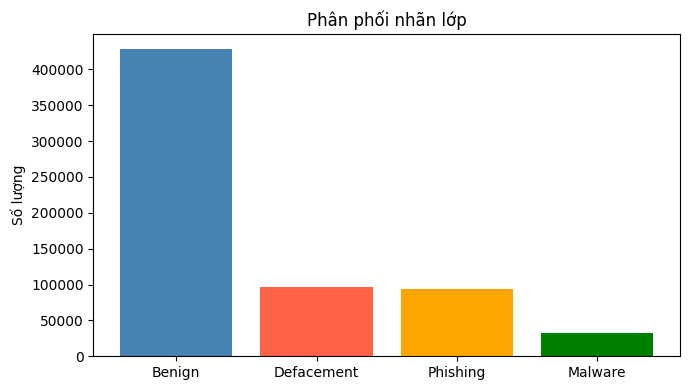

In [5]:
label_map = {0: 'Benign', 1: 'Defacement', 2: 'Phishing', 3: 'Malware'}

print("=== PHÂN PHỐI NHÃN ===")
print(df['label'].value_counts())
print(f"\nTỷ lệ (%):\n{df['label'].value_counts(normalize=True).round(3) * 100}")

plt.figure(figsize=(7, 4))
counts = df['label'].value_counts().sort_index()
plt.bar([label_map[i] for i in counts.index], counts.values,
        color=['steelblue', 'tomato', 'orange', 'green'])
plt.title('Phân phối nhãn lớp')
plt.ylabel('Số lượng')
plt.tight_layout()
plt.show()

## 4. Kiểm Tra Cột Dạng Text
Dataset có 4 cột text: `url`, `type`, `domain`, `scan_date`.  
Với các mô hình Machine learning do không đọc được text thô nên sẽ bị loại. Riêng cột `url` sẽ được giữ lại cho Deep Learning.

In [6]:
print(df.select_dtypes(include='object').columns.tolist())
df.select_dtypes(include='object').head(3)

['url', 'type', 'domain', 'scan_date']


C:\Users\ngoca\AppData\Local\Temp\ipykernel_29104\2238448109.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include='object').columns.tolist())
C:\Users\ngoca\AppData\Local\Temp\ipykernel_29104\2238448109.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_gu

,url,type,domain,scan_date
0,br-icloud.com.br,phishing,br-icloud.com.br,2025-12-03 14:53:31
1,mp3raid.com/music/krizz_kaliko.html,benign,mp3raid.com,2025-12-03 14:53:31
2,bopsecrets.org/rexroth/cr/1.htm,benign,bopsecrets.org,2025-12-03 14:53:31


## 5. Tạo 2 Pipeline Dữ Liệu

ML và DL "nhìn" data theo 2 cách hoàn toàn khác nhau, nên cần 2 pipeline riêng:

- **`df_tab`** Machine learning pipeline: giữ 59 features số, bỏ hết cột text
- **`df_seq`** Deep learning pipeline: chỉ giữ cột `url` để model tự học từ chuỗi ký tự

In [7]:
# Pipeline 1: df_tab dùng cho machine leanring
df_tab = df.drop(columns=['url', 'type', 'domain', 'scan_date'])

# Xử lý missing values
df_tab = df_tab.fillna(df_tab.median(numeric_only=True))

print("df_tab (ML pipeline)")
print(f"Shape: {df_tab.shape}")
print(f"Missing values: {df_tab.isnull().sum().sum()}")

# Pipeline 2: df_seq dùng cho deep learning
df_seq = df[['url', 'label']].copy()

print(f"\ndf_seq (Deep Learning pipeline)")
print(f"Shape: {df_seq.shape}")
print(f"Missing values: {df_seq.isnull().sum().sum()}")

df_tab (ML pipeline)
Shape: (651191, 60)
Missing values: 0

df_seq (Deep Learning pipeline)
Shape: (651191, 2)
Missing values: 0


## 6. Chia Tập Train / Test

Chia 80/20. Dùng `stratify=y` để tỷ lệ 4 lớp trong train và test giống nhau, tránh trường hợp một tập bị thiếu hẳn lớp Malware.

In [8]:
X = df_tab.drop(columns=['label'])
y = df_tab['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nTrain label distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))
print(f"\nTest label distribution (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

X_train: (520952, 59)
X_test:  (130239, 59)

Train label distribution (%):
label
0    65.74
1    14.81
2    14.45
3     4.99
Name: proportion, dtype: float64

Test label distribution (%):
label
0    65.74
1    14.81
2    14.45
3     4.99
Name: proportion, dtype: float64


## 7. Chuẩn Hóa Dữ Liệu

Một số features có giá trị chênh nhau rất lớn (ví dụ `url_len` max = 2175 trong khi nhiều features chỉ là 0/1). Nếu không chuẩn hóa, các model nhạy với khoảng cách như KNN hay SVM sẽ bị ảnh hưởng.

Scaler chỉ `fit` trên **train set**, sau đó `transform` cả hai. Nếu fit trên toàn bộ data là **data leakage** model đã biết thông tin test trước khi đánh giá.

In [9]:
scaler = StandardScaler()

# Fit trên train, transform cả train và test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert lại về DataFrame 
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"X_train_scaled mean (5 cột đầu):\n{X_train_scaled.iloc[:, :5].mean().round(4)}")

X_train_scaled mean (5 cột đầu):
url_len    0.0
@          0.0
?         -0.0
-          0.0
=         -0.0
dtype: float64


## 8. Ma Trận Tương Quan Giữa Các Features

Xem các features có liên quan với nhau không. Các cụm màu đậm cho thấy nhóm features đang mang thông tin tương tự nhau.

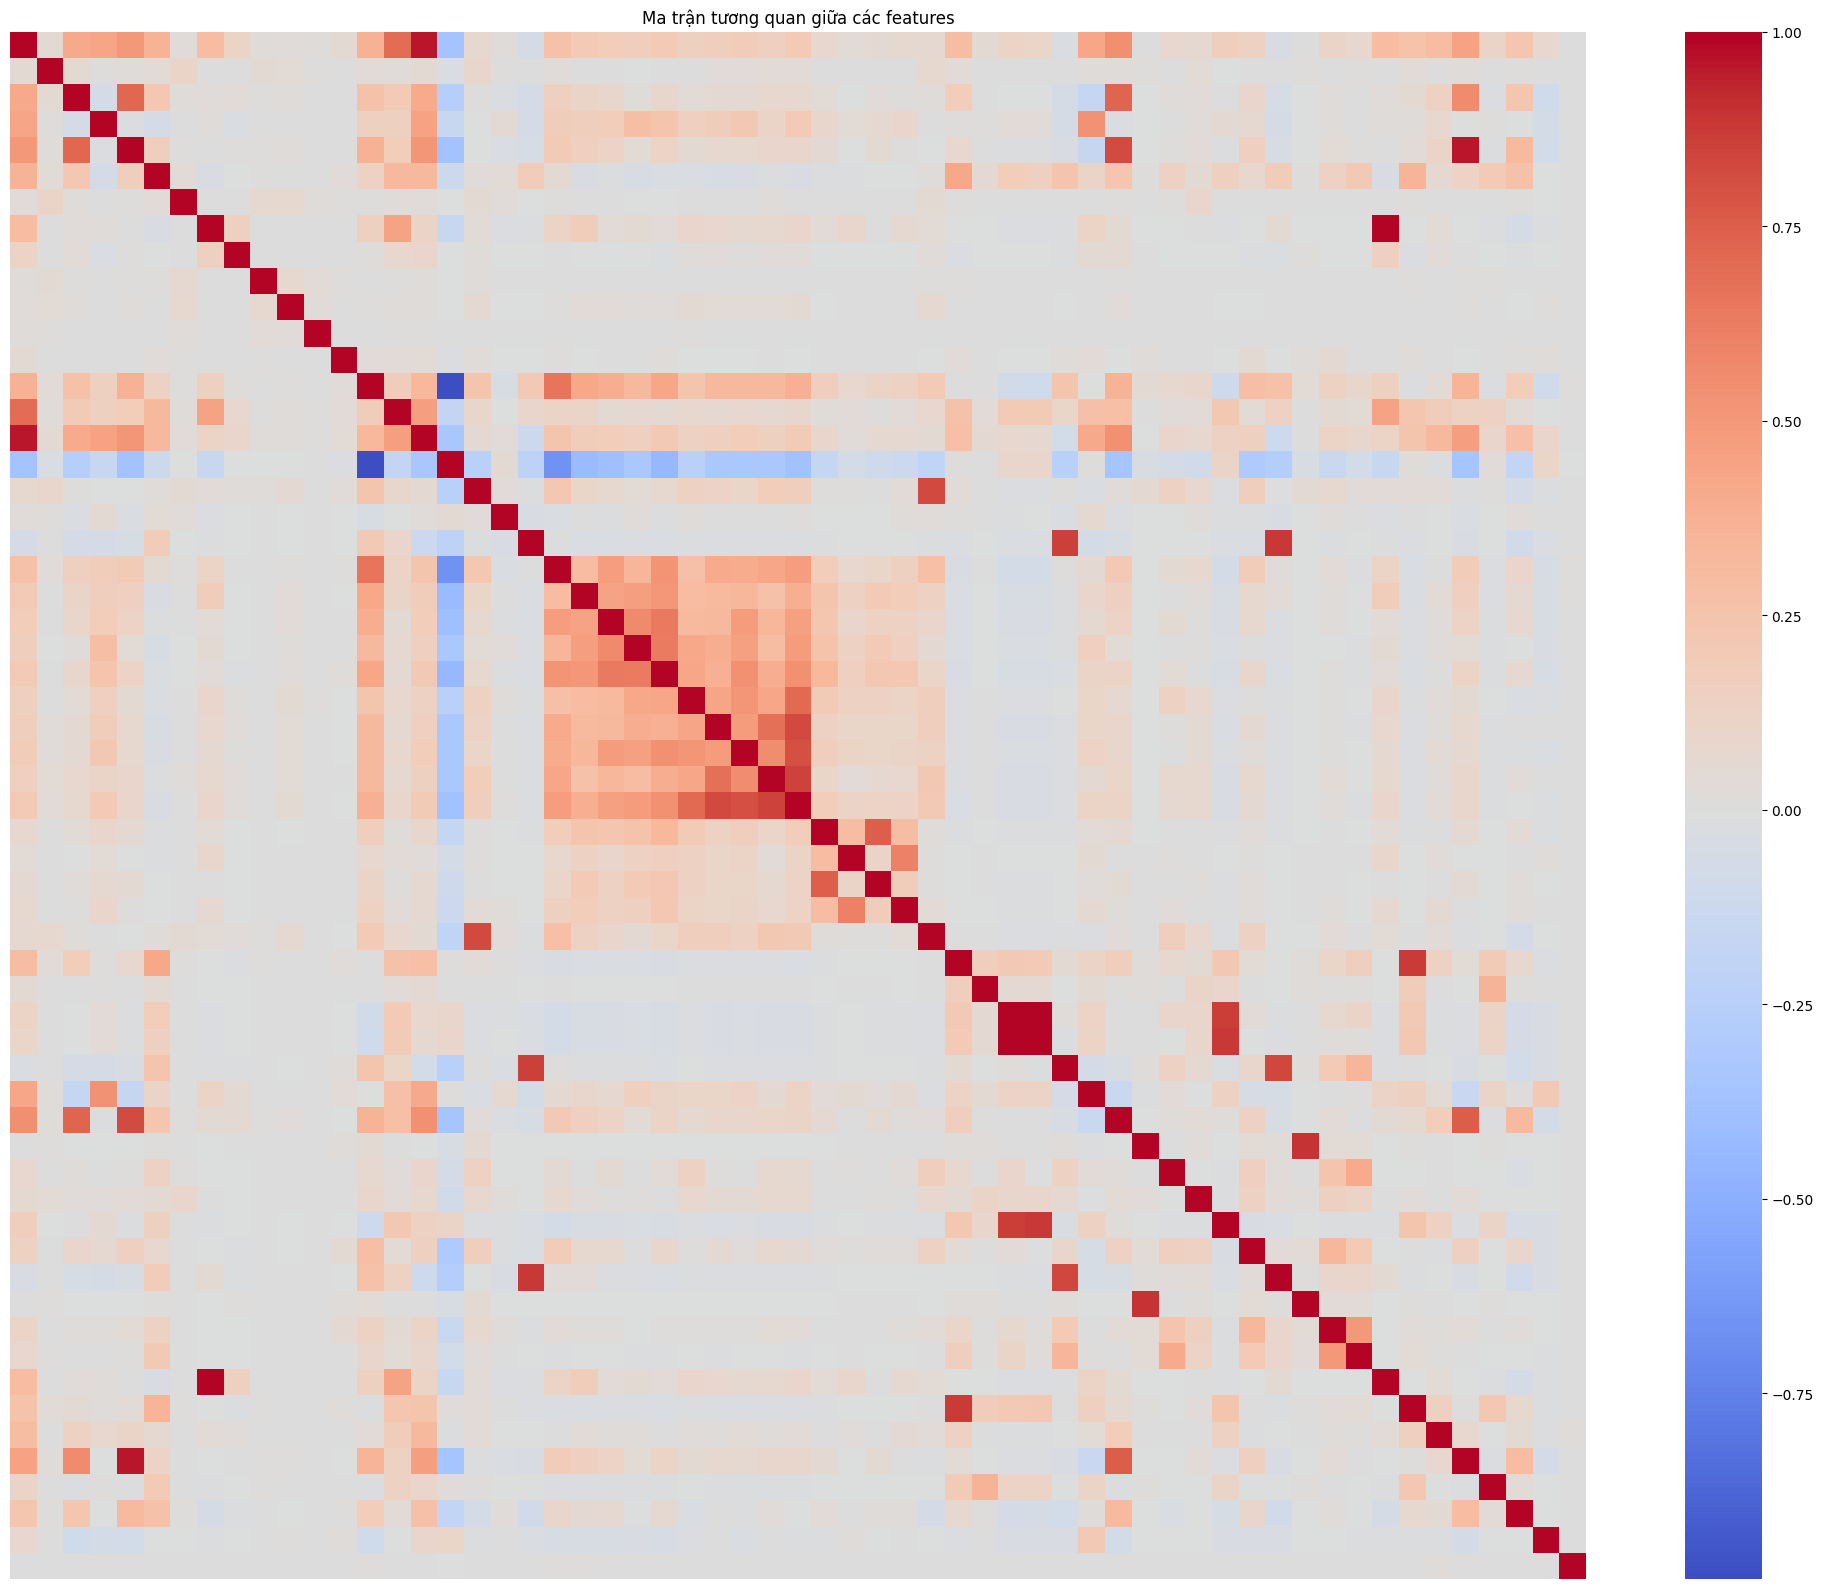

In [10]:
plt.figure(figsize=(20, 16))
corr_matrix = df_tab.drop(columns=['label']).corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            xticklabels=False, yticklabels=False)
plt.title('Ma trận tương quan giữa các features')
plt.tight_layout()
plt.show()

## 9. Top 15 Features Tương Quan Cao Nhất Với Nhãn

Feature cao nhất là `abnormal_url` với tương quan ~0.48 vẫn chưa đủ để một mình phân loại chính xác. Điều này cho thấy bài toán cần model học được **tổ hợp nhiều features** cùng lúc, không phải dựa vào một feature duy nhất.

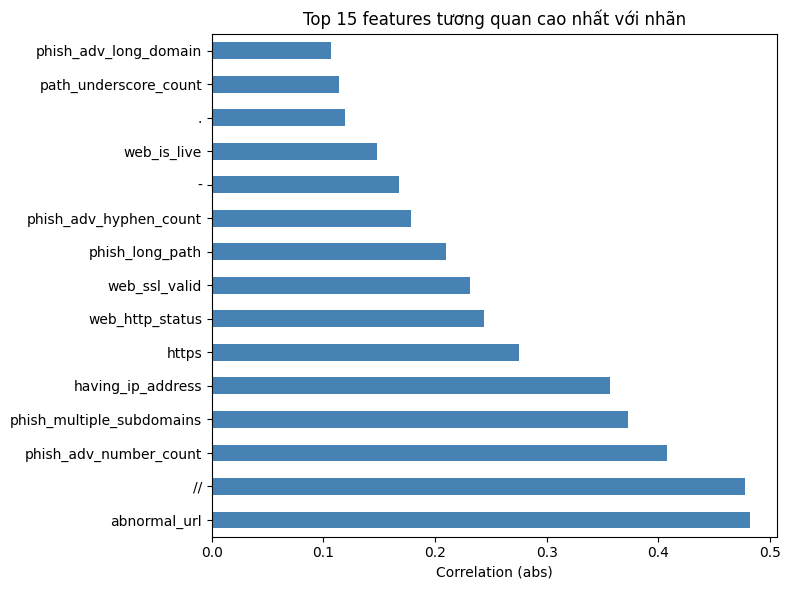

abnormal_url                 0.482234
//                           0.478059
phish_adv_number_count       0.408036
phish_multiple_subdomains    0.373286
having_ip_address            0.356658
https                        0.274931
web_http_status              0.243707
web_ssl_valid                0.231723
phish_long_path              0.209968
phish_adv_hyphen_count       0.178614
-                            0.167712
web_is_live                  0.148324
.                            0.119474
path_underscore_count        0.113656
phish_adv_long_domain        0.106455
Name: label, dtype: float64


In [11]:
corr_with_label = df_tab.corr()['label'].abs().sort_values(ascending=False)
top_features = corr_with_label[1:16]

plt.figure(figsize=(8, 6))
top_features.plot(kind='barh', color='steelblue')
plt.title('Top 15 features tương quan cao nhất với nhãn')
plt.xlabel('Correlation (abs)')
plt.tight_layout()
plt.show()

print(top_features)

## 10. Phân Phối Feature Quan Trọng Theo Từng Lớp

Nhìn vào giá trị trung bình của top 5 features để xem chúng phân biệt các lớp như thế nào. Nếu các lớp có giá trị khác nhau rõ ràng thì feature đó thực sự hữu ích.

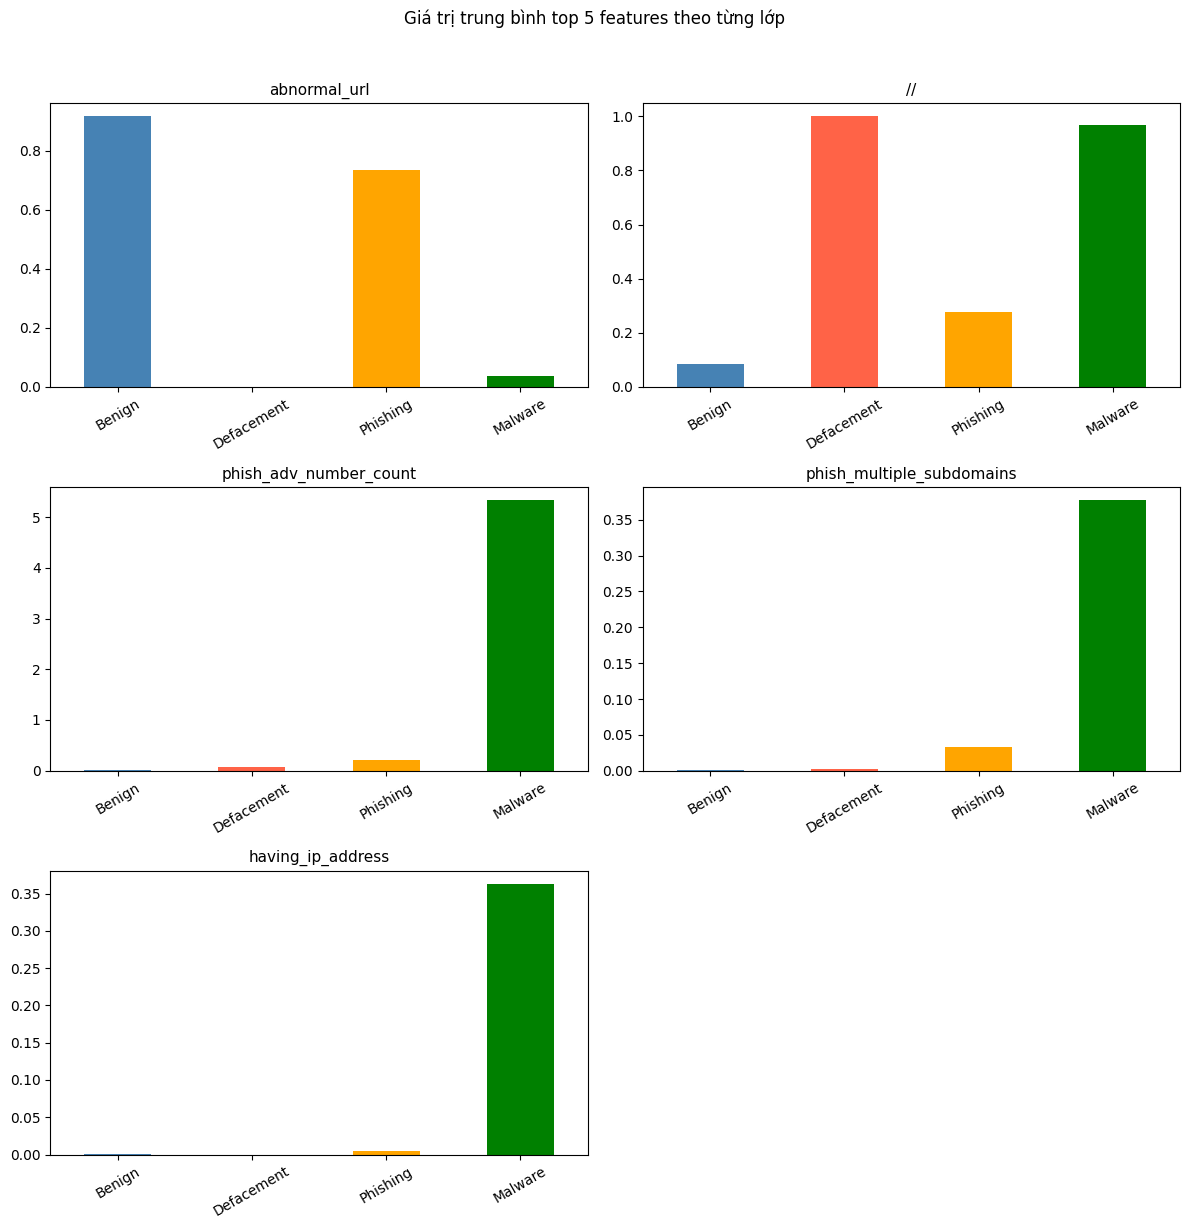

In [12]:
top5 = ['abnormal_url', '//', 'phish_adv_number_count',
        'phish_multiple_subdomains', 'having_ip_address']

label_names = {0: 'Benign', 1: 'Defacement', 2: 'Phishing', 3: 'Malware'}

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, feat in enumerate(top5):
    df_tab.groupby('label')[feat].mean().rename(label_names).plot(
        kind='bar', ax=axes[i], color=['steelblue','tomato','orange','green']
    )
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

axes[5].set_visible(False)

plt.suptitle('Giá trị trung bình top 5 features theo từng lớp', y=1.02)
plt.tight_layout()
plt.show()